In [2]:
%pip install pandas numpy matplotlib --quiet


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
# Import necessary libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'svg'

print("Libraries imported successfully!")

# Connect to the SQLite database
conn = sqlite3.connect("inventory.db")

# Create a cursor object to interact with the database
cursor = conn.cursor()

# Function to run a SQL query and return the results as a DataFrame
def run_query_to_df(cursor, query):
    cursor.execute(query)
    rows = cursor.fetchall()
    
    # Get column names from cursor
    columns = []
    for col in cursor.description:
        columns.append(col[0])

    # Convert to DataFrame
    df = pd.DataFrame(rows, columns = columns)

    return df

Libraries imported successfully!


In [11]:
query = """
SELECT oi.quantity, s.days_scheduled, s.days_actual,
       (s.days_actual / s.days_scheduled) * 100 AS late_risk_rate
FROM orders AS o
JOIN customers  AS c  ON o.customer_id = c.id
JOIN shipping   AS s  ON o.id = s.order_id
JOIN order_items AS oi ON o.id = oi.order_id
ORDER BY oi.quantity DESC, s.late_delivery_risk
LIMIT 10
"""

# Call the function to run the query and display results
result = run_query_to_df(cursor, query)
result

,quantity,days_scheduled,days_actual,late_risk_rate
0,5,4.0,3.0,75.0
1,5,4.0,4.0,100.0
2,5,4.0,2.0,50.0
3,5,4.0,3.0,75.0
4,5,4.0,3.0,75.0
5,5,4.0,2.0,50.0
6,5,4.0,2.0,50.0
7,5,4.0,3.0,75.0
8,5,4.0,2.0,50.0
9,5,4.0,4.0,100.0


In [12]:
query = """
SELECT round(AVG(days_actual/days_scheduled)*100,2) AS avg_late_risk_rate FROM orders AS o

JOIN customers as c
ON o.customer_id = c.id

JOIN shipping as s
ON o.id = s.order_id
"""

# Call the function to run the query and display results
result = run_query_to_df(cursor, query)
result

,avg_late_risk_rate
0,136.66


In [13]:
query = """
SELECT s.shipping_mode,
       SUM(s.days_actual)    AS total_days_actual,
       SUM(s.days_scheduled) AS total_days_scheduled,
       ROUND(SUM(s.days_actual) * 1.0 / SUM(s.days_scheduled), 4) AS actual_vs_scheduled_ratio
FROM orders AS o
JOIN customers AS c ON o.customer_id = c.id
JOIN shipping  AS s ON o.id = s.order_id
GROUP BY s.shipping_mode
ORDER BY actual_vs_scheduled_ratio DESC
"""

# Call the function to run the query and display results
result = run_query_to_df(cursor, query)
result

,shipping_mode,total_days_actual,total_days_scheduled,actual_vs_scheduled_ratio
0,First Class,17572.0,8786.0,2.0000
1,Second Class,44508.0,22256.0,1.9998
2,Standard Class,137211.0,137324.0,0.9992
3,Same Day,1482.0,0.0,NaN


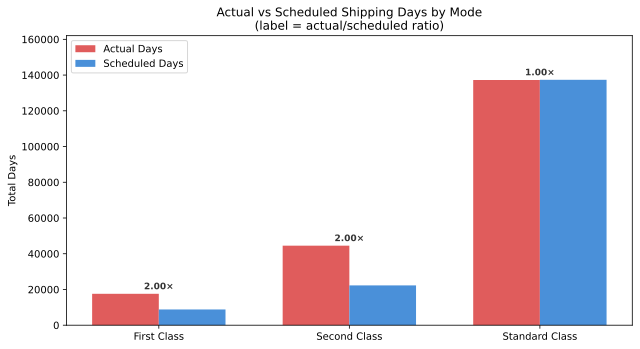

In [14]:
df_plot = result[result['actual_vs_scheduled_ratio'].notna()].copy().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(df_plot))
width = 0.35

bars_actual    = ax.bar(x - width/2, df_plot['total_days_actual'],    width, label='Actual Days',    color='#e05c5c')
bars_scheduled = ax.bar(x + width/2, df_plot['total_days_scheduled'], width, label='Scheduled Days', color='#4a90d9')

for i, row in df_plot.iterrows():
    top = max(row['total_days_actual'], row['total_days_scheduled'])
    ax.text(i, top + 1500, f"{row['actual_vs_scheduled_ratio']:.2f}×",
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333')

ax.set_xticks(x)
ax.set_xticklabels(df_plot['shipping_mode'])
ax.set_ylabel('Total Days')
ax.set_title('Actual vs Scheduled Shipping Days by Mode\n(label = actual/scheduled ratio)')
ax.legend()
ax.set_ylim(0, df_plot[['total_days_actual', 'total_days_scheduled']].max().max() * 1.18)
plt.tight_layout()
plt.show()

In [16]:
query = """
SELECT
    substr(order_date, instr(order_date, ' ') - 4, 4) || '-' ||
    printf('%02d', CAST(substr(order_date, 1, instr(order_date, '/') - 1) AS INTEGER))
        AS year_month,

    SUM(late_delivery_risk), COUNT(*) AS total_orders,
    ROUND(SUM(late_delivery_risk)*1.0/COUNT(*),2) AS late_risk

FROM orders AS o

JOIN shipping as s
ON s.order_id = o.id

GROUP BY year_month
ORDER BY year_month;
"""
# Call the function to run the query and display results
result = run_query_to_df(cursor, query)
result

,year_month,SUM(late_delivery_risk),total_orders,late_risk
0,2015-01,963,1787,0.54
1,2015-02,871,1585,0.55
2,2015-03,978,1781,0.55
3,2015-04,927,1710,0.54
4,2015-05,969,1776,0.55
5,2015-06,941,1725,0.55
6,2015-07,963,1763,0.55
7,2015-08,966,1762,0.55
8,2015-09,951,1706,0.56
9,2015-10,973,1775,0.55


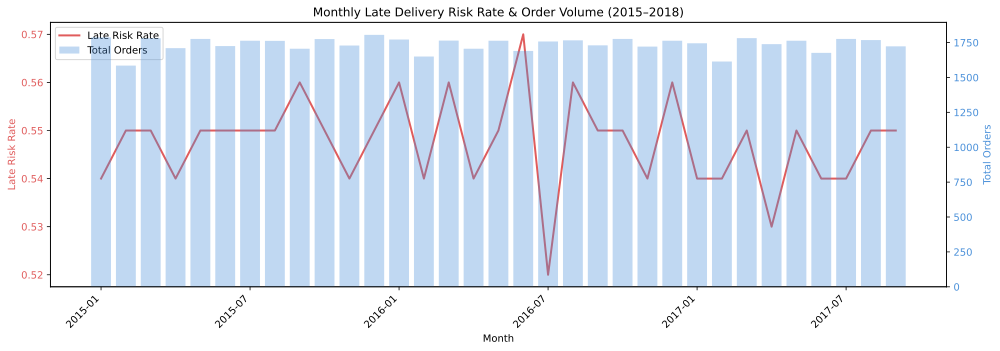

In [17]:
fig, ax1 = plt.subplots(figsize=(14, 5))

x = np.arange(len(result))

ax2 = ax1.twinx()
ax2.bar(x, result['total_orders'], color='#4a90d9', alpha=0.35, label='Total Orders')
ax2.set_ylabel('Total Orders', color='#4a90d9')
ax2.tick_params(axis='y', labelcolor='#4a90d9')

ax1.plot(x, result['late_risk'], color='#e05c5c', linewidth=2, label='Late Risk Rate', zorder=3)
ax1.set_ylabel('Late Risk Rate', color='#e05c5c')
ax1.tick_params(axis='y', labelcolor='#e05c5c')

tick_step = 6
ax1.set_xticks(x[::tick_step])
ax1.set_xticklabels(result['year_month'].iloc[::tick_step], rotation=45, ha='right')

ax1.set_title('Monthly Late Delivery Risk Rate & Order Volume (2015–2018)')
ax1.set_xlabel('Month')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()